# Analyse du Sweep Male Factor

Comparaison des modèles entraînés avec différentes valeurs de `male_factor` (surpondération des hommes dans la loss).

**Prérequis** : récupérer les résultats depuis le cluster :
```bash
scp -r ivars-25@gpu-gw.enst.fr:~/Data-Challenge-Telecom-Paris-Face-Occlusion/data/submissions/checkpoints/sweep_mf_* data/submissions/checkpoints/
```

In [3]:
import os, sys, json, glob, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if "__vsc_ipynb_file__" in dir():
    PROJECT_ROOT = os.path.dirname(os.path.dirname(os.path.abspath(__vsc_ipynb_file__)))
else:
    PROJECT_ROOT = os.path.abspath("..") if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)
print(f"Working directory: {os.getcwd()}")
%matplotlib inline

Working directory: /home/leo/Data_Challenge_Telecom/Data-Challenge-Telecom-Paris-Face-Occlusion


## 1. Charger tous les runs

In [4]:
def file_hash(path):
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

sweep_dirs = sorted(glob.glob("data/submissions/checkpoints/sweep_mf_*"))
if not sweep_dirs:
    raise FileNotFoundError("Aucun dossier sweep_mf trouvé.")

print(f"{len(sweep_dirs)} sweep(s) trouvés :")
for d in sweep_dirs:
    print(f"  {d}")

runs = []
seen = set()
for sweep_dir in sweep_dirs:
    for run_dir in sorted(glob.glob(os.path.join(sweep_dir, "mf_*"))):
        # Support history.json or history_fold0.json
        history_candidates = glob.glob(os.path.join(run_dir, "history*.json"))
        if not history_candidates:
            continue
        history_path = sorted(history_candidates)[0]
        h_hash = file_hash(history_path)
        if h_hash in seen:
            continue
        seen.add(h_hash)
        with open(history_path) as f:
            h = json.load(f)
        mf = float(os.path.basename(run_dir).replace("mf_", ""))
        best_idx = int(np.argmin(h["val_score"]))
        runs.append({
            "male_factor": mf,
            "sweep": os.path.basename(sweep_dir),
            "dir": run_dir,
            "history": h,
            "best_epoch": h["epoch"][best_idx],
            "best_score": h["val_score"][best_idx],
            "best_err_f": h["err_f"][best_idx],
            "best_err_m": h["err_m"][best_idx],
            "best_gap": abs(h["err_f"][best_idx] - h["err_m"][best_idx]),
        })

df = pd.DataFrame([{k: v for k, v in r.items() if k != "history"} for r in runs])
df = df.sort_values(["sweep", "male_factor"]).reset_index(drop=True)
print(f"\n{len(runs)} runs uniques chargés")
df

5 sweep(s) trouvés :
  data/submissions/checkpoints/sweep_mf_20260609_052529
  data/submissions/checkpoints/sweep_mf_20260609_064622
  data/submissions/checkpoints/sweep_mf_20260609_085551
  data/submissions/checkpoints/sweep_mf_20260609_103432
  data/submissions/checkpoints/sweep_mf_20260609_114514

5 runs uniques chargés


,male_factor,sweep,dir,best_epoch,best_score,best_err_f,best_err_m,best_gap
0,1.0,sweep_mf_20260609_052529,data/submissions/checkpoints/sweep_mf_20260609...,20,0.001847,0.000758,0.001484,0.000726
1,1.5,sweep_mf_20260609_064622,data/submissions/checkpoints/sweep_mf_20260609...,10,0.001837,0.000788,0.001487,0.000699
2,2.0,sweep_mf_20260609_085551,data/submissions/checkpoints/sweep_mf_20260609...,12,0.001790,0.001088,0.001556,0.000468
3,2.5,sweep_mf_20260609_103432,data/submissions/checkpoints/sweep_mf_20260609...,27,0.001886,0.000650,0.001474,0.000824
4,3.0,sweep_mf_20260609_114514,data/submissions/checkpoints/sweep_mf_20260609...,12,0.001657,0.001070,0.001461,0.000391


## 2. Tableau récapitulatif

In [5]:
best = df.loc[df["best_score"].idxmin()]

print(f"{'mf':>6} {'score':>10} {'err_f':>10} {'err_m':>10} {'gap':>10} {'epoch':>6}  sweep")
print("-" * 75)
for _, row in df.iterrows():
    marker = " <-- BEST" if (row["male_factor"] == best["male_factor"] and row["sweep"] == best["sweep"]) else ""
    print(f"{row['male_factor']:>6.2f} {row['best_score']:>10.6f} {row['best_err_f']:>10.6f} "
          f"{row['best_err_m']:>10.6f} {row['best_gap']:>10.6f} {int(row['best_epoch']):>6}  {row['sweep']}{marker}")

print(f"\n→ Meilleur : male_factor={best['male_factor']}, score={best['best_score']:.6f} ({best['sweep']})")

    mf      score      err_f      err_m        gap  epoch  sweep
---------------------------------------------------------------------------
  1.00   0.001847   0.000758   0.001484   0.000726     20  sweep_mf_20260609_052529
  1.50   0.001837   0.000788   0.001487   0.000699     10  sweep_mf_20260609_064622
  2.00   0.001790   0.001088   0.001556   0.000468     12  sweep_mf_20260609_085551
  2.50   0.001886   0.000650   0.001474   0.000824     27  sweep_mf_20260609_103432
  3.00   0.001657   0.001070   0.001461   0.000391     12  sweep_mf_20260609_114514 <-- BEST

→ Meilleur : male_factor=3.0, score=0.001657 (sweep_mf_20260609_114514)


## 3. Score en fonction du male_factor

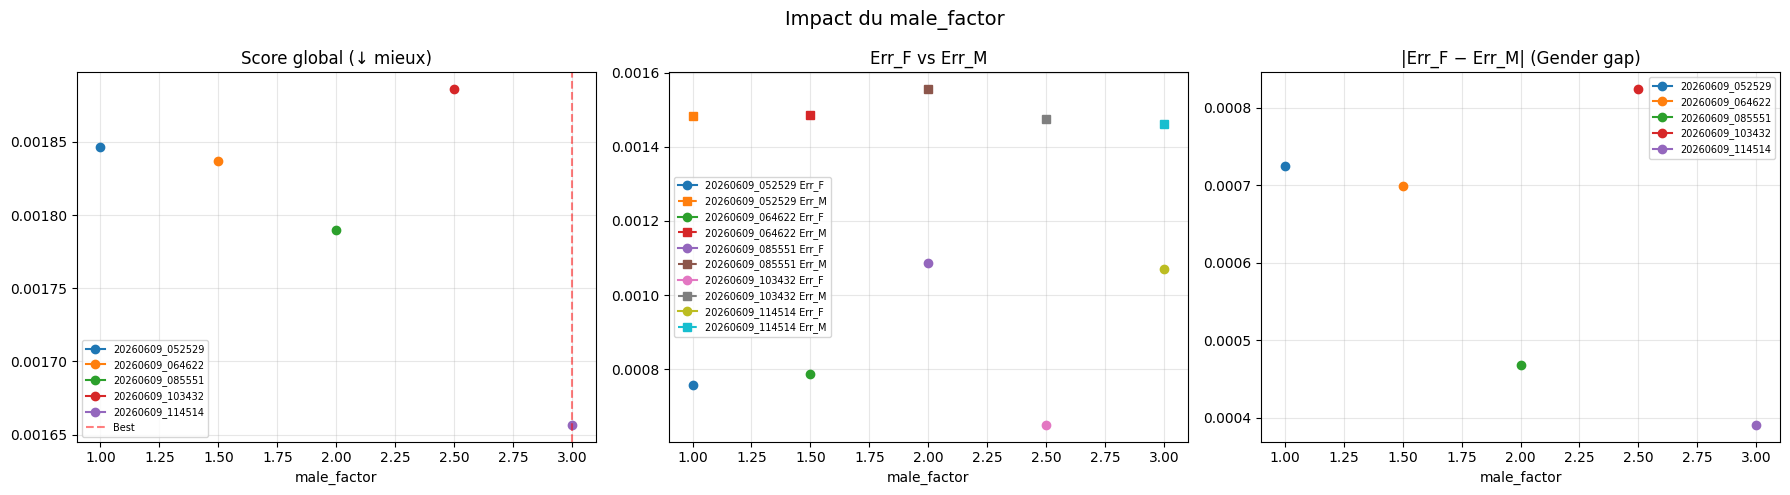

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for sweep_name, gdf in df.groupby("sweep"):
    gdf = gdf.sort_values("male_factor")
    label = sweep_name.replace("sweep_mf_", "")
    axes[0].plot(gdf["male_factor"], gdf["best_score"], "o-", label=label)
    axes[1].plot(gdf["male_factor"], gdf["best_err_f"], "o-", label=f"{label} Err_F")
    axes[1].plot(gdf["male_factor"], gdf["best_err_m"], "s--", label=f"{label} Err_M")
    axes[2].plot(gdf["male_factor"], gdf["best_gap"], "o-", label=label)

axes[0].set_title("Score global (↓ mieux)")
axes[0].set_xlabel("male_factor")
axes[0].axvline(best["male_factor"], color="red", linestyle="--", alpha=0.5, label="Best")
axes[0].legend(fontsize=7); axes[0].grid(True, alpha=0.3)

axes[1].set_title("Err_F vs Err_M")
axes[1].set_xlabel("male_factor")
axes[1].legend(fontsize=7); axes[1].grid(True, alpha=0.3)

axes[2].set_title("|Err_F − Err_M| (Gender gap)")
axes[2].set_xlabel("male_factor")
axes[2].legend(fontsize=7); axes[2].grid(True, alpha=0.3)

plt.suptitle("Impact du male_factor", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Courbes d'entraînement du meilleur run

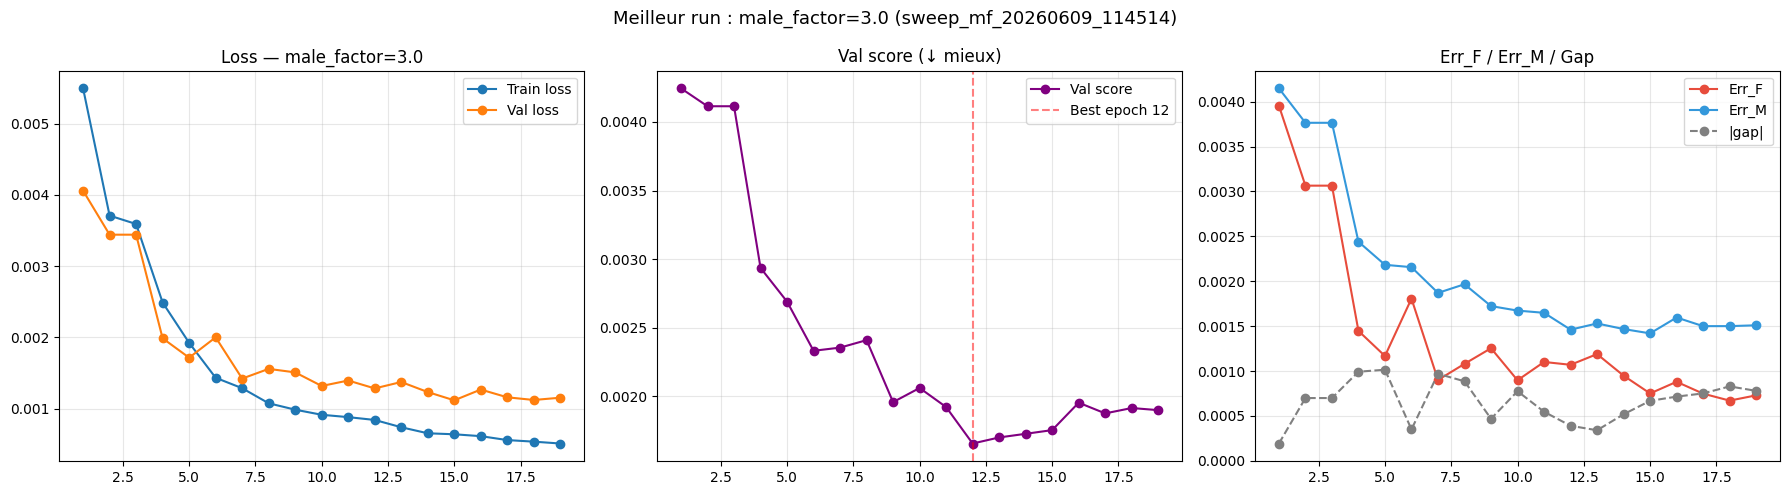

In [7]:
best_run = runs[df["best_score"].idxmin()]
h = best_run["history"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(h["epoch"], h["train_loss"], "o-", label="Train loss")
axes[0].plot(h["epoch"], h["val_loss"], "o-", label="Val loss")
axes[0].set_title(f"Loss — male_factor={best_run['male_factor']}")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(h["epoch"], h["val_score"], "o-", color="purple", label="Val score")
axes[1].axvline(best_run["best_epoch"], color="red", linestyle="--", alpha=0.5,
                label=f"Best epoch {best_run['best_epoch']}")
axes[1].set_title("Val score (↓ mieux)")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

gap = [abs(f - m) for f, m in zip(h["err_f"], h["err_m"])]
axes[2].plot(h["epoch"], h["err_f"], "o-", color="#e74c3c", label="Err_F")
axes[2].plot(h["epoch"], h["err_m"], "o-", color="#3498db", label="Err_M")
axes[2].plot(h["epoch"], gap, "o--", color="gray", label="|gap|")
axes[2].set_title("Err_F / Err_M / Gap")
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle(f"Meilleur run : male_factor={best_run['male_factor']} ({best_run['sweep']})", fontsize=13)
plt.tight_layout()
plt.show()